# Meilenstein 2: Data Exploration - Univariate Analyse

## 1. Kontext
Im vorherigen Notebook ([04_Data_Cleaning_Exploration.ipynb](04_Data_Cleaning_Exploration.ipynb)) wurde der Datensatz technisch bereinigt und als `05_cleaned_master_data.pkl` gespeichert. Alle Spalten liegen jetzt in den korrekten Datentypen vor (Numerisch, Datum, Kategorial).

## 2. Zielsetzung dieses Notebooks
Dieser erste Abschnitt der **Data Exploration** beschäftigt sich ausschließlich mit der **univariaten Analyse**, also der isolierten Betrachtung einzelner Spalten. Die Ziele sind:

- **Skalen verstehen:** Welcher Spaltentyp (kontinuierlich, ordinal, nominal, zirkulär, ID, Datum) liegt vor und welche Maße sind dafür sinnvoll?
- **Datenqualität quantifizieren:** Wie viele Missing Values gibt es pro Spalte, und sind diese systematisch (z. B. DNF) oder Datenfehler?
- **Verteilungen erkennen:** Histogramme und Boxplots zeigen Schiefe, Modalität und potenzielle Ausreißer.
- **Outlier identifizieren:** IQR-Methode liefert eine erste, methodisch saubere Outlier-Quantifizierung.

## 3. Vorgehensweise
1. **Statistik-Tabellen** pro Skalentyp (numerisch, kategorial, Datum/Geo).
2. **Missing-Value-Analyse** mit Domänenkontext.
3. **Zielvariable `rank`** separat behandelt, da `NaN` hier DNF/DNS bedeutet.
4. **Verteilungen thematisch gruppiert:** Renn-Features, Fahrer-Biometrie, Spezialisierungspunkte, Wetter.
5. **Skewness-Ranking** als Indikator für notwendige Transformationen.
6. **IQR-basierte Outlier-Detection** mit Tabelle und Boxplot-Visualisierung.
7. **Kategoriale Bar Charts** der häufigsten Ausprägungen.

> Hinweis: Dieses Notebook ist **read-only** auf den Daten. Es werden keine Spalten verändert oder neue Pickle-Dateien geschrieben - das passiert erst im Imputations-/Encoding-Schritt.

In [ ]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

DATA_PATH = "../../data/processed/05_cleaned_master_data.pkl"
df = pd.read_pickle(DATA_PATH)

print(f"Shape: {df.shape[0]:,} Zeilen x {df.shape[1]} Spalten")
print("\nDatentypen:")
print(df.dtypes.value_counts())


Shape: 225,692 Zeilen x 48 Spalten

Datentypen:
float64           31
object            13
int64              2
datetime64[ns]     2
Name: count, dtype: int64


## Spaltenrollen statt Datentypen

Reine `dtype`-Erkennung reicht hier nicht aus, weil mehrere numerische Spalten **inhaltlich** keine Verteilungsstatistik vertragen:
- `year`, `stage_nr` sind **ordinal** (Mittelwerte sind sinnlos).
- `departure_windrichtung_mittel`, `arrival_windrichtung_mittel` sind **zirkulär** (0° = 360°, lineare Statistik unzulässig).
- `*_lat`, `*_lon` sind **geographische Koordinaten** (eindimensionale Verteilung wenig informativ).
- `url`, `rider_url`, `name`, `url_name` sind **Identifikatoren** (hochkardinal, keine Verteilung).
- `rank` ist die **Zielvariable** mit Domänensemantik (`NaN` = DNF/DNS) und wird separat behandelt.

Wir bauen daher manuelle Listen pro Rolle und nutzen sie konsistent in allen folgenden Auswertungen.

In [2]:
def _filter_existing(cols, df):
    return [c for c in cols if c in df.columns]


target = _filter_existing(["rank"], df)

id_like = _filter_existing(
    ["url", "rider_url", "url_name", "name", "image_url"], df
)

temporal = _filter_existing(["birthdate", "date"], df)

geo = _filter_existing(
    ["departure_lat", "departure_lon", "arrival_lat", "arrival_lon"], df
)

circular = _filter_existing(
    ["departure_windrichtung_mittel", "arrival_windrichtung_mittel"], df
)

categorical = _filter_existing(
    [
        "race",
        "nationality",
        "won_how",
        "team_class",
        "current_team",
        "departure",
        "arrival",
        "race_ranking",
        "time_gap",
    ],
    df,
)

ordinal_int = _filter_existing(["year", "stage_nr"], df)

excluded = set(target + id_like + temporal + geo + circular + categorical + ordinal_int)
numeric_continuous = [
    c for c in df.select_dtypes(include=np.number).columns if c not in excluded
]

print(f"target            ({len(target):2d}): {target}")
print(f"id_like           ({len(id_like):2d}): {id_like}")
print(f"temporal          ({len(temporal):2d}): {temporal}")
print(f"geo               ({len(geo):2d}): {geo}")
print(f"circular          ({len(circular):2d}): {circular}")
print(f"categorical       ({len(categorical):2d}): {categorical}")
print(f"ordinal_int       ({len(ordinal_int):2d}): {ordinal_int}")
print(f"numeric_continuous({len(numeric_continuous):2d}): {numeric_continuous}")


target            ( 1): ['rank']
id_like           ( 4): ['url', 'rider_url', 'url_name', 'name']
temporal          ( 2): ['birthdate', 'date']
geo               ( 4): ['departure_lat', 'departure_lon', 'arrival_lat', 'arrival_lon']
circular          ( 2): ['departure_windrichtung_mittel', 'arrival_windrichtung_mittel']
categorical       ( 9): ['race', 'nationality', 'won_how', 'team_class', 'current_team', 'departure', 'arrival', 'race_ranking', 'time_gap']
ordinal_int       ( 2): ['year', 'stage_nr']
numeric_continuous(24): ['height', 'weight', 'distance', 'vertical_meters', 'profile_score', 'avg_speed', 'one_day_races', 'gc', 'time_trial', 'sprint', 'climber', 'hills', 'departure_temp_mittel', 'departure_regen_mittel', 'departure_wind_mittel', 'departure_luftfeuchte_mittel', 'departure_niederschlag_mittel', 'arrival_temp_mittel', 'arrival_regen_mittel', 'arrival_wind_mittel', 'arrival_luftfeuchte_mittel', 'arrival_niederschlag_mittel', 'rider_points_season', 'rider_rank_season']


## Univariate Statistik-Tabellen

Wir produzieren drei Tabellen, weil unterschiedliche Skalen unterschiedliche Maße verlangen:

| Skalentyp | Sinnvolle Maße |
|---|---|
| **Numerisch kontinuierlich / ordinal-int** | `count`, `missing`, `mean`, `std`, `var`, `min`, `Q1`, `Median`, `Q3`, `max`, `IQR`, `skew`, `kurtosis`, `mode`, `n_unique` |
| **Kategorial nominal** | `count`, `missing`, `n_unique`, `mode`, `mode_freq`, `mode_share_pct`, `top5` |
| **ID-Spalten (hochkardinal)** | nur `n_unique` und `n_duplicates` (Verteilungsstatistik nicht aussagekräftig) |
| **Datum** | `min`, `max`, `span_days`, `missing` |
| **Geo (Bounding Box)** | `min`, `max`, `mean` als reiner Plausibilitäts-Check |

> Hinweis: `mode` wird auch für kontinuierliche Variablen mitgeführt, ist dort aber meist wenig aussagekräftig (oft nur ein zufällig häufiger Wert). `rank` wird **nicht** in dieser Tabelle aggregiert, sondern später separat behandelt.

In [3]:
def numeric_summary(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    n_total = len(df)
    for col in cols:
        s = df[col]
        s_clean = s.dropna()
        n_missing = int(s.isna().sum())
        if len(s_clean) == 0:
            rows.append(
                {"column": col, "count": 0, "n_missing": n_missing, "missing_pct": 100.0}
            )
            continue
        q1, median, q3 = np.percentile(s_clean, [25, 50, 75])
        mode_vals = s_clean.mode()
        mode_first = mode_vals.iloc[0] if not mode_vals.empty else np.nan
        rows.append(
            {
                "column": col,
                "count": int(s_clean.shape[0]),
                "n_missing": n_missing,
                "missing_pct": round(100 * n_missing / n_total, 2),
                "mean": s_clean.mean(),
                "std": s_clean.std(),
                "var": s_clean.var(),
                "min": s_clean.min(),
                "q1": q1,
                "median": median,
                "q3": q3,
                "max": s_clean.max(),
                "iqr": q3 - q1,
                "skew": stats.skew(s_clean, bias=False),
                "kurtosis": stats.kurtosis(s_clean, bias=False),
                "mode": mode_first,
                "n_unique": int(s_clean.nunique()),
            }
        )
    return pd.DataFrame(rows).set_index("column")


numeric_cols = numeric_continuous + ordinal_int
num_stats = numeric_summary(df, numeric_cols).round(3)
num_stats


,count,n_missing,missing_pct,mean,std,var,min,q1,median,q3,max,iqr,skew,kurtosis,mode,n_unique
column,,,,,,,,,,,,,,,,
height,221760,3932,1.74,1.801,0.064,0.004,1.590,1.750,1.80,1.840,2.04,0.090,0.007,-0.092,1.80,41
weight,221760,3932,1.74,68.185,6.386,40.779,48.000,63.000,68.00,72.000,94.00,9.000,0.240,-0.077,70.00,53
distance,225692,0,0.00,161.202,59.175,3501.719,0.000,153.400,177.00,196.500,264.00,43.100,-1.476,1.396,0.00,571
vertical_meters,220380,5312,2.35,2452.557,1417.634,2009685.942,0.000,1349.000,2387.00,3518.000,6939.00,2169.000,0.202,-0.681,732.00,1138
profile_score,220380,5312,2.35,138.735,126.016,15880.044,0.000,31.000,100.00,229.000,515.00,198.000,0.839,-0.352,0.00,400
avg_speed,225539,153,0.07,41.197,5.050,25.507,18.666,38.066,41.00,43.813,58.83,5.747,0.350,1.597,43.33,1158
one_day_races,225692,0,0.00,1243.496,1734.809,3009561.693,0.000,285.000,647.00,1484.000,15708.00,1199.000,3.479,16.359,0.00,1141
gc,225692,0,0.00,1578.111,1834.456,3365228.950,0.000,469.000,951.00,1838.000,13732.00,1369.000,2.531,8.315,0.00,1193
time_trial,225692,0,0.00,771.109,1326.378,1759279.478,0.000,67.000,263.00,923.000,12022.00,856.000,3.565,17.464,0.00,804


In [4]:
def categorical_summary(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    n_total = len(df)
    for col in cols:
        s = df[col].astype("object")
        n_missing = int(s.isna().sum())
        s_clean = s.dropna()
        if len(s_clean) == 0:
            rows.append(
                {"column": col, "count": 0, "n_missing": n_missing, "missing_pct": 100.0}
            )
            continue
        vc = s_clean.value_counts()
        mode_val = vc.index[0]
        mode_freq = int(vc.iloc[0])
        top5 = ", ".join(f"{idx} ({cnt})" for idx, cnt in vc.head(5).items())
        rows.append(
            {
                "column": col,
                "count": int(s_clean.shape[0]),
                "n_missing": n_missing,
                "missing_pct": round(100 * n_missing / n_total, 2),
                "n_unique": int(s_clean.nunique()),
                "mode": mode_val,
                "mode_freq": mode_freq,
                "mode_share_pct": round(100 * mode_freq / s_clean.shape[0], 2),
                "top5": top5,
            }
        )
    return pd.DataFrame(rows).set_index("column")


cat_stats = categorical_summary(df, categorical)
cat_stats


,count,n_missing,missing_pct,n_unique,mode,mode_freq,mode_share_pct,top5
column,,,,,,,,
race,225692,0,0.00,3,giro-d-italia,75721,33.55,"giro-d-italia (75721), tour-de-france (75190),..."
nationality,222818,2874,1.27,63,IT,34142,15.32,"IT (34142), FR (30828), ES (29941), BE (17397)..."
won_how,225692,0,0.00,206,Sprint of large group,66115,29.29,"Sprint of large group (66115), Sprint of small..."
team_class,219326,6366,2.82,5,WT,145264,66.23,"WT (145264), PT (35774), PCT (27890), PRT (103..."
current_team,219326,6366,2.82,242,Movistar Team,7445,3.39,"Movistar Team (7445), AG2R La Mondiale (6580),..."
departure,225692,0,0.00,938,Pau,2687,1.19,"Pau (2687), Granada (1208), Albertville (1159)..."
arrival,225692,0,0.00,906,Madrid,2670,1.18,"Madrid (2670), Paris (2659), Lagos de Covadong..."
race_ranking,225692,0,0.00,10,n/a,164674,72.96,"n/a (164674), 1 (20747), 11 (7027), 8 (6833), ..."
time_gap,225692,0,0.00,6755,",,0:00",40004,17.73,",,0:00 (40004), n/a (5186), ,,0:05 (1199), ,,0..."


In [5]:
def id_summary(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    n_total = len(df)
    for col in cols:
        s = df[col]
        s_clean = s.dropna()
        n_unique = int(s_clean.nunique())
        rows.append(
            {
                "column": col,
                "count": int(s_clean.shape[0]),
                "n_missing": int(s.isna().sum()),
                "n_unique": n_unique,
                "n_duplicates": int(s_clean.shape[0] - n_unique),
                "uniqueness_pct": round(100 * n_unique / max(s_clean.shape[0], 1), 2),
            }
        )
    return pd.DataFrame(rows).set_index("column")


id_stats = id_summary(df, id_like)
id_stats


,count,n_missing,n_unique,n_duplicates,uniqueness_pct
column,,,,,
url,225692,0,1312,224380,0.58
rider_url,225692,0,2118,223574,0.94
url_name,222818,2874,2001,220817,0.90
name,222818,2874,2001,220817,0.90


In [6]:
def temporal_summary(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    rows = []
    n_total = len(df)
    for col in cols:
        s = pd.to_datetime(df[col], errors="coerce")
        s_clean = s.dropna()
        if s_clean.empty:
            rows.append({"column": col, "min": None, "max": None, "span_days": None})
            continue
        rows.append(
            {
                "column": col,
                "count": int(s_clean.shape[0]),
                "n_missing": int(s.isna().sum()),
                "missing_pct": round(100 * s.isna().sum() / n_total, 2),
                "min": s_clean.min(),
                "max": s_clean.max(),
                "span_days": (s_clean.max() - s_clean.min()).days,
            }
        )
    return pd.DataFrame(rows).set_index("column")


temporal_stats = temporal_summary(df, temporal)
temporal_stats


,count,n_missing,missing_pct,min,max,span_days
column,,,,,,
birthdate,222818,2874,1.27,1968-03-26,2005-02-14,13474
date,225692,0,0.00,2005-05-08,2025-09-14,7434


In [7]:
geo_stats = (
    df[geo]
    .agg(["count", "min", "max", "mean"])
    .T.rename(columns={"count": "count_non_null"})
    .round(4)
)
geo_stats["n_missing"] = df[geo].isna().sum().values
geo_stats


,count_non_null,min,max,mean,n_missing
departure_lat,222377.0,-28.5866,59.4372,43.4665,3315
departure_lon,222377.0,-118.3000,120.9060,3.2311,3315
arrival_lat,214253.0,-38.4732,59.4372,43.7670,11439
arrival_lon,214253.0,-118.3000,35.2258,3.6164,11439


## Missing Values

`NaN` ist im Domänenkontext **nicht zwangsläufig ein Datenfehler**, sondern oft eine eigene Information. Vor jeder Imputationsentscheidung sollten wir die Ursache verstehen:

| Spalte(n) | Wahrscheinliche Ursache | Empfehlung |
|---|---|---|
| `rank` | Fahrer hat das Rennen nicht beendet (DNF/DNS/DSQ) | **NICHT** imputieren - DNF separat als Zielinformation modellieren |
| `rider_points_season`, `rider_rank_season` | Rookie-Saison oder erstes Profijahr ohne Vorsaisonpunkte | Mit `0` imputieren oder als "Rookie"-Flag kodieren |
| `weight`, `height` | Fahrerprofil nicht vollständig auf procyclingstats | Median (gruppiert nach `nationality`/Jahr) sinnvoll |
| Wetter-Spalten | Geo-Lookup ohne Treffer (z. B. Bergpass ohne nahe Station) | Median des jeweiligen Renntags / Etappe |
| `current_team`, `team_class` | Zeitraum ohne Vertrag, Übergangsphasen | Forward-Fill auf Fahrerebene oder "unknown"-Kategorie |

Wir zeigen jetzt nur die **Quantifizierung** - die Imputationsstrategien gehören in den nächsten Notebookschritt.

Spalten mit Missings: 30 von 48


,n_missing,missing_pct
arrival_windrichtung_mittel,11439,5.07
arrival_niederschlag_mittel,11439,5.07
arrival_temp_mittel,11439,5.07
arrival_regen_mittel,11439,5.07
arrival_wind_mittel,11439,5.07
arrival_lon,11439,5.07
arrival_lat,11439,5.07
arrival_luftfeuchte_mittel,11439,5.07
team_class,6366,2.82
current_team,6366,2.82


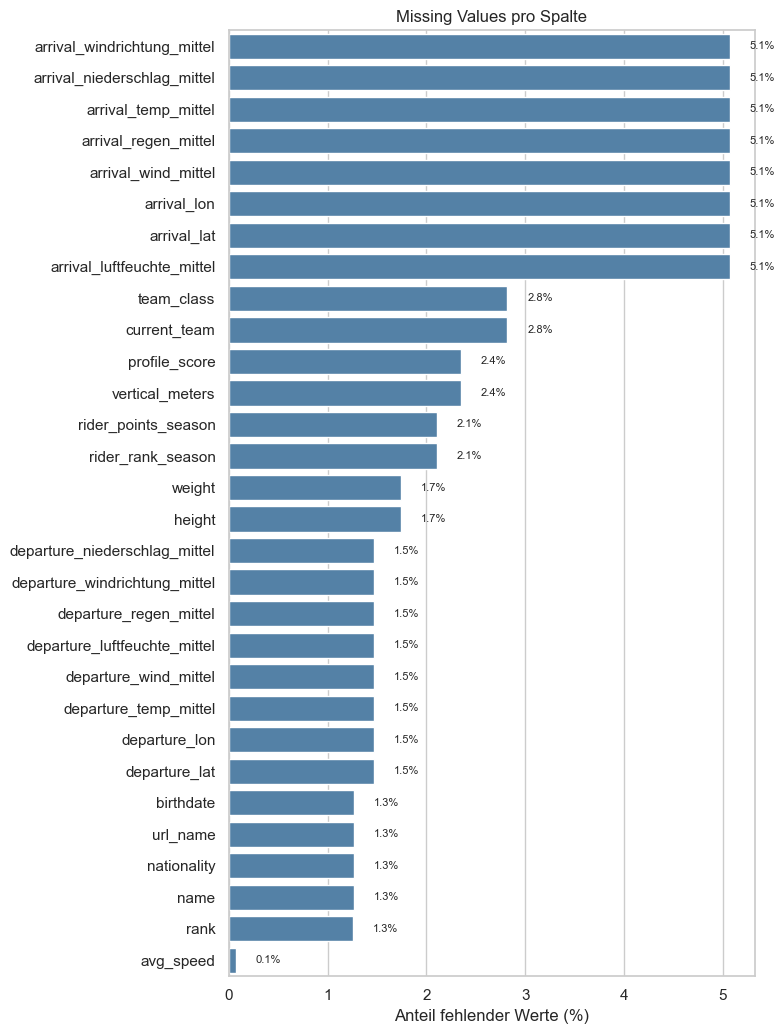

In [8]:
missing_counts = df.isna().sum()
missing_table = (
    pd.DataFrame(
        {
            "n_missing": missing_counts,
            "missing_pct": (100 * missing_counts / len(df)).round(2),
        }
    )
    .query("n_missing > 0")
    .sort_values("missing_pct", ascending=False)
)

print(f"Spalten mit Missings: {len(missing_table)} von {df.shape[1]}")
display(missing_table)

if not missing_table.empty:
    fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(missing_table))))
    sns.barplot(
        x=missing_table["missing_pct"],
        y=missing_table.index,
        ax=ax,
        color="steelblue",
    )
    ax.set_xlabel("Anteil fehlender Werte (%)")
    ax.set_ylabel("")
    ax.set_title("Missing Values pro Spalte")
    for i, v in enumerate(missing_table["missing_pct"]):
        ax.text(v + 0.2, i, f"{v:.1f}%", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Keine Missing Values im Datensatz.")


## Zielvariable `rank`

`rank` ist die Zielvariable für unser späteres Ranking-Modell. Wir behandeln sie aus zwei Gründen separat:

1. **`NaN` ist Information, kein Fehler:** Fahrer, die ausgestiegen sind (DNF/DNS/DSQ/OTL), bekommen keinen Rang. Im allgemeinen `mean`/`std` würden sie als "missing" verschwinden und das Bild verzerren.
2. **Ranking-Skala ist unbalanciert:** Es gibt sehr viele schlechte Plätze, aber nur wenige Top-10-Plätze. Eine reine Verteilungsstatistik überschattet, dass die Top-Bereiche besonders relevant sind.

Gesamt-Starts: 225,692
DNF/DNS (rank == NaN): 2,852 (1.26 %)
Gefinishte Plaetze:    222,840

Statistik der gefinishten Raenge:
count       222840.00
mean            86.31
std             50.54
min              1.00
5%               9.00
25%             43.00
50%             85.00
75%            128.00
95%            168.00
max            207.00
skew             0.09
kurtosis        -1.08
Name: rank, dtype: float64


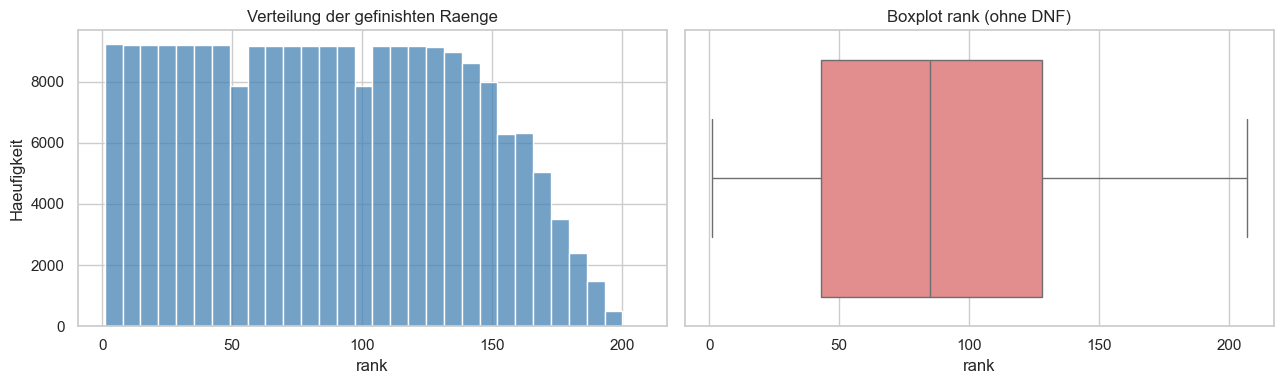

In [9]:
rank_series = df["rank"]
n_total = len(rank_series)
n_dnf = int(rank_series.isna().sum())
dnf_pct = 100 * n_dnf / n_total

print(f"Gesamt-Starts: {n_total:,}")
print(f"DNF/DNS (rank == NaN): {n_dnf:,} ({dnf_pct:.2f} %)")
print(f"Gefinishte Plaetze:    {n_total - n_dnf:,}")
print()

rank_finished = rank_series.dropna()
desc = rank_finished.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95])
desc.loc["skew"] = stats.skew(rank_finished, bias=False)
desc.loc["kurtosis"] = stats.kurtosis(rank_finished, bias=False)
print("Statistik der gefinishten Raenge:")
print(desc.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(rank_finished, bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Verteilung der gefinishten Raenge")
axes[0].set_xlabel("rank")
axes[0].set_ylabel("Haeufigkeit")

sns.boxplot(x=rank_finished, ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot rank (ohne DNF)")
axes[1].set_xlabel("rank")

plt.tight_layout()
plt.show()


## Verteilungen - thematisch gruppiert

Statt 30+ einzelne Plots produzieren wir **Histogramm- und Boxplot-Grids** pro inhaltlicher Gruppe. So lassen sich Vergleiche innerhalb einer Gruppe (z. B. "Wie sind alle Wetter-Spalten verteilt?") leichter ziehen, ohne die Übersicht zu verlieren.

Die Hilfsfunktion `plot_grid` rendert ein einheitliches Subplot-Gitter und nutzen wir mehrfach.

In [10]:
def plot_grid(
    df: pd.DataFrame,
    cols: list[str],
    kind: str = "hist",
    ncols: int = 3,
    bins: int = 40,
    figsize_per_cell: tuple = (4.5, 3.2),
    title: str | None = None,
    color: str = "steelblue",
):
    cols = [c for c in cols if c in df.columns]
    if not cols:
        print("Keine darstellbaren Spalten.")
        return
    nrows = int(np.ceil(len(cols) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_cell[0] * ncols, figsize_per_cell[1] * nrows),
    )
    axes = np.atleast_1d(axes).flatten()

    for ax, col in zip(axes, cols):
        s = df[col].dropna()
        if s.empty:
            ax.set_visible(False)
            continue
        if kind == "hist":
            sns.histplot(s, bins=bins, ax=ax, color=color, kde=False)
            ax.set_ylabel("Haeufigkeit")
        elif kind == "box":
            sns.boxplot(x=s, ax=ax, color=color)
            ax.set_xlabel(col)
        else:
            raise ValueError(f"Unbekannter kind: {kind}")
        ax.set_title(col, fontsize=10)
        if kind == "hist":
            ax.set_xlabel(col)

    for ax in axes[len(cols):]:
        ax.set_visible(False)

    if title:
        fig.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


### Gruppe 1: Renn-Features

`distance` (km), `vertical_meters` (Höhenmeter), `profile_score` (Schwierigkeitsindex), `avg_speed` (km/h) und `stage_nr` charakterisieren das Etappenprofil. Hier interessieren uns vor allem:
- Bimodalität bei `avg_speed` (Zeitfahren vs. Massenstart),
- Häufung bei `vertical_meters = 0` (Flachetappen) und sehr hohen Werten (Bergankünfte),
- Plausibilität von `stage_nr` (in einer Grand Tour 1-21).

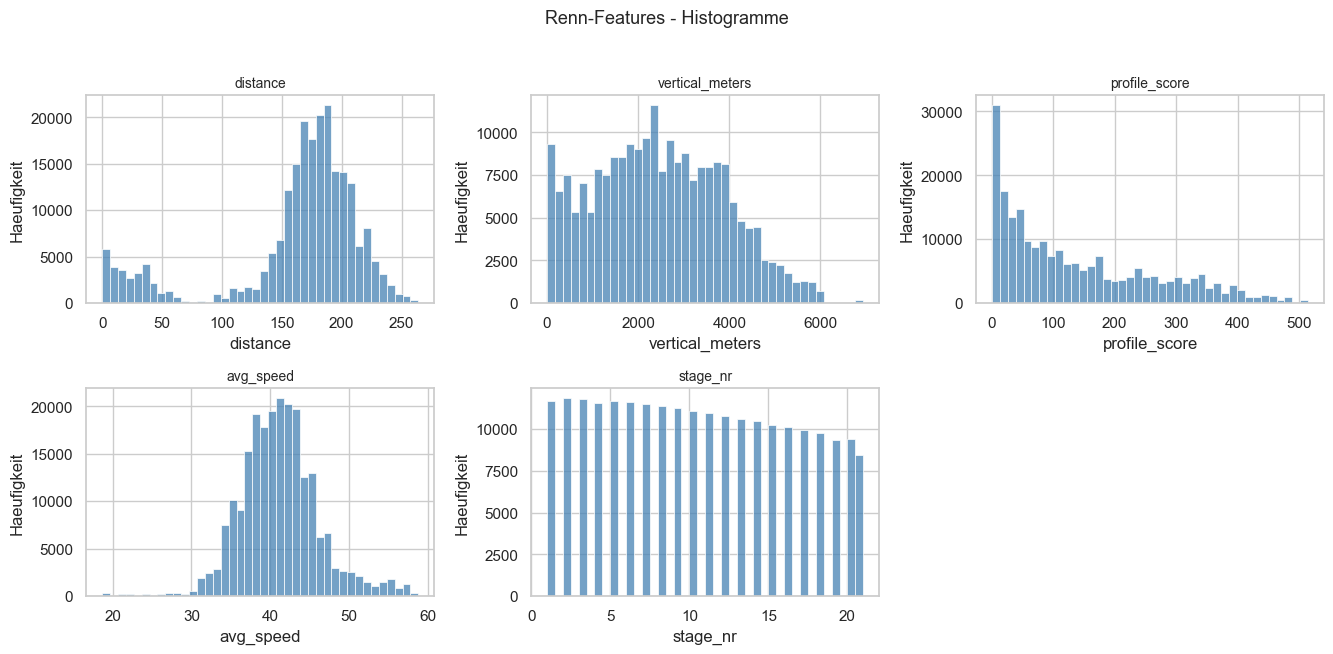

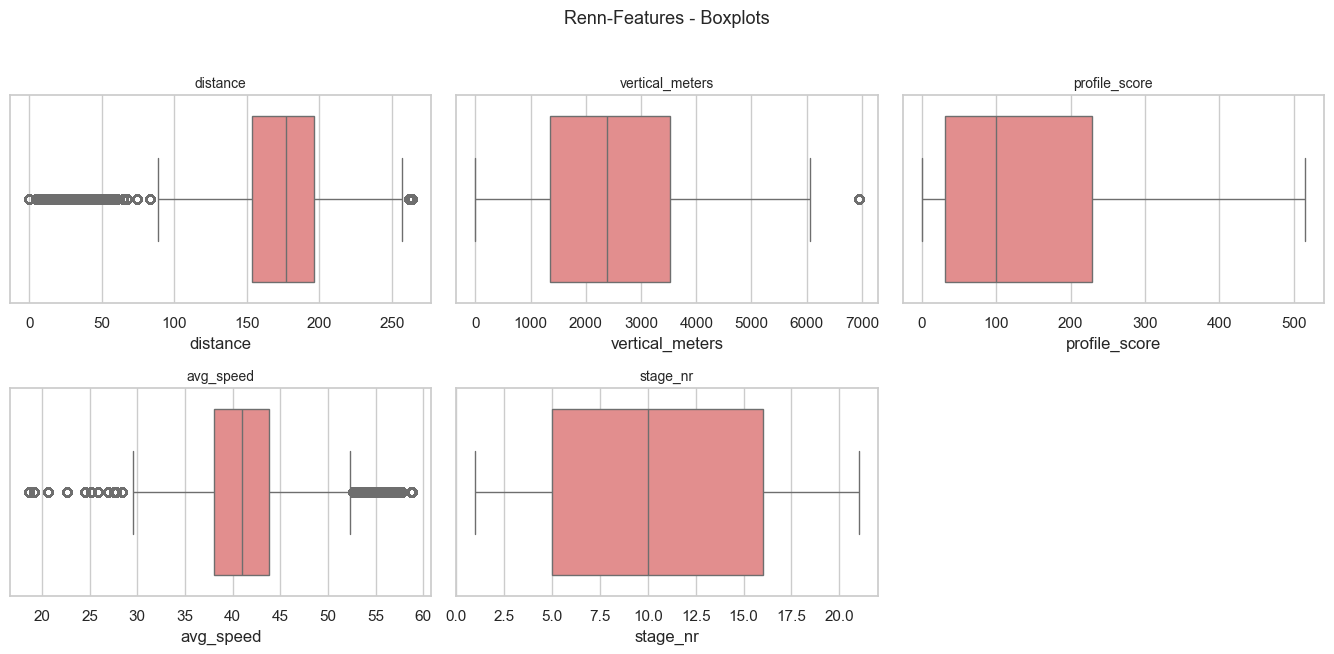

In [11]:
race_cols = ["distance", "vertical_meters", "profile_score", "avg_speed", "stage_nr"]
race_cols = [c for c in race_cols if c in df.columns]

plot_grid(df, race_cols, kind="hist", ncols=3, title="Renn-Features - Histogramme")
plot_grid(df, race_cols, kind="box", ncols=3, color="lightcoral", title="Renn-Features - Boxplots")


### Gruppe 2: Fahrer-Biometrie

`height` (m) und `weight` (kg) sollten näherungsweise normalverteilt sein (typisches Profi-Profil ca. 1.70-1.90 m, 60-80 kg). Zusätzlich berechnen wir das **Alter zum Renntag** als temporäre Hilfsgröße - nur für die Visualisierung, nicht persistent.

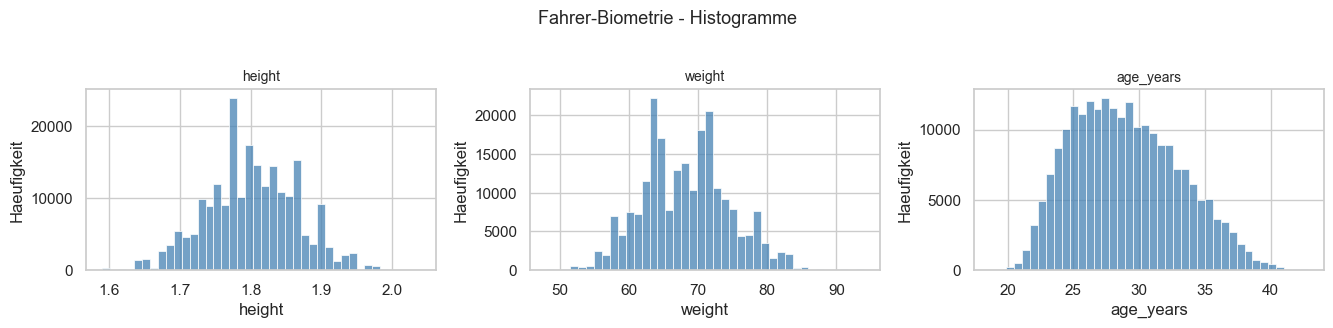

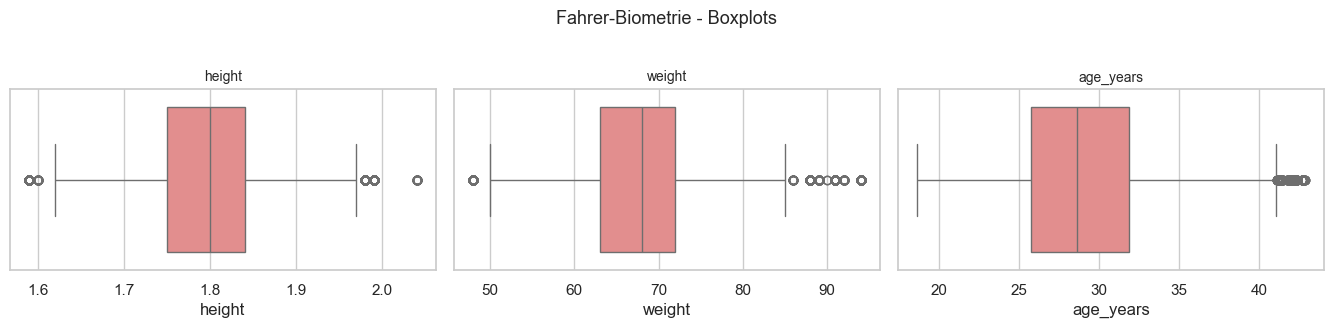

In [12]:
bio_df = df[["height", "weight"]].copy()
if {"date", "birthdate"}.issubset(df.columns):
    age_years = (
        pd.to_datetime(df["date"], errors="coerce")
        - pd.to_datetime(df["birthdate"], errors="coerce")
    ).dt.days / 365.25
    bio_df["age_years"] = age_years

plot_grid(
    bio_df,
    list(bio_df.columns),
    kind="hist",
    ncols=3,
    title="Fahrer-Biometrie - Histogramme",
)
plot_grid(
    bio_df,
    list(bio_df.columns),
    kind="box",
    ncols=3,
    color="lightcoral",
    title="Fahrer-Biometrie - Boxplots",
)


### Gruppe 3: Spezialisierungspunkte

procyclingstats vergibt Spezialisten-Scores für `one_day_races`, `gc`, `time_trial`, `sprint`, `climber`, `hills` plus die akkumulierten `rider_points_season`. Diese Scores sind **stark rechtsschief**: Die meisten Fahrer haben wenig Punkte, einige Top-Fahrer dominieren.

Wir zeigen daher zwei Sichten:
1. Histogramm in **linearer Skala** - macht die Schiefe sichtbar.
2. Histogramm in **`log1p`-Skala** - macht die Verteilung im Niedrigwertbereich sichtbar und hilft bei der Entscheidung über Log-Transformationen für das Modell.

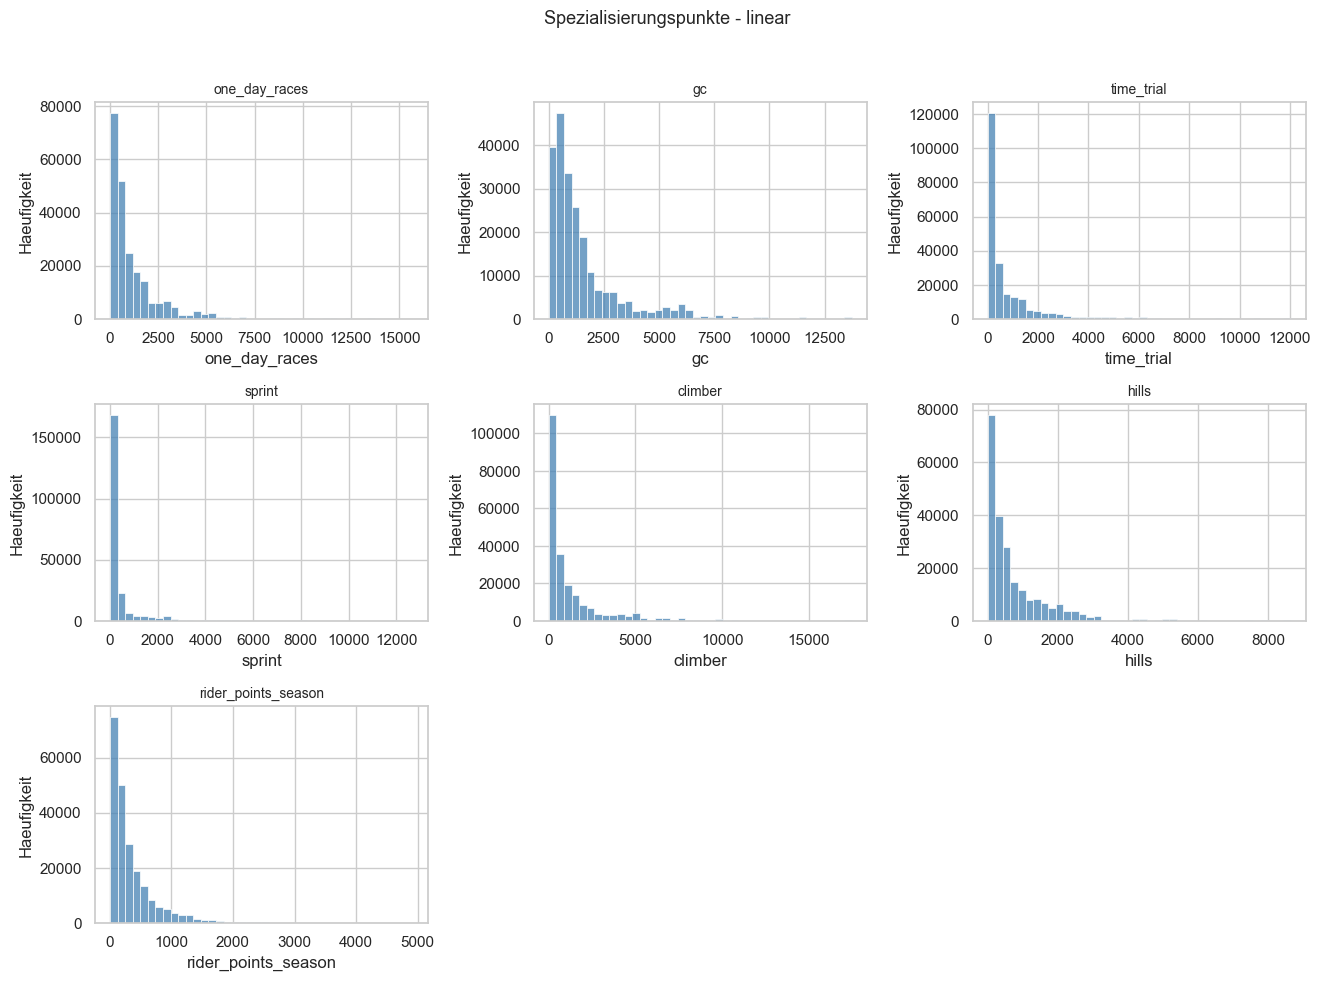

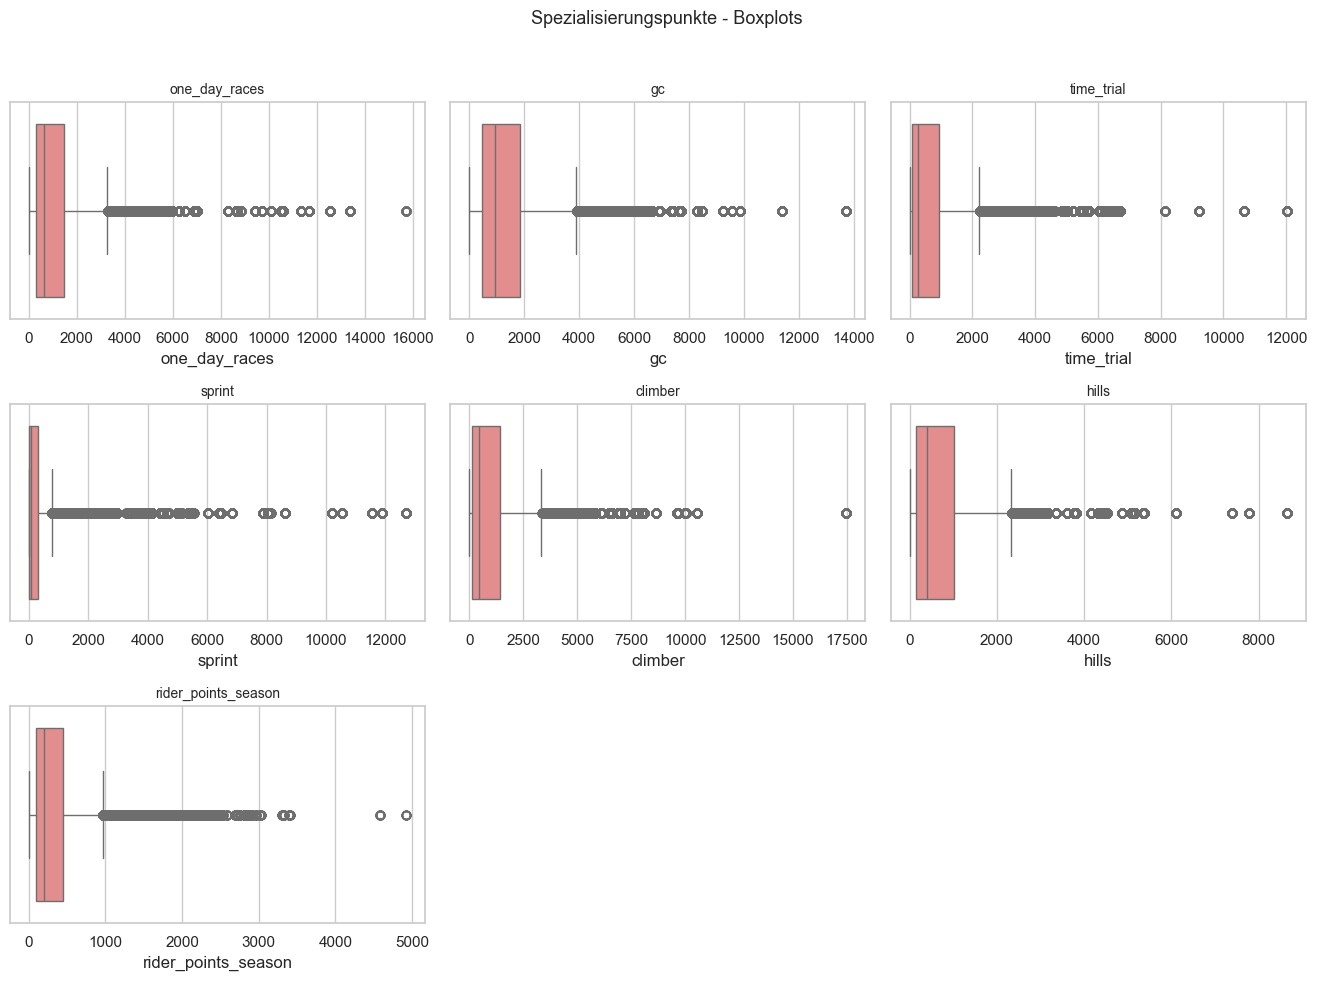

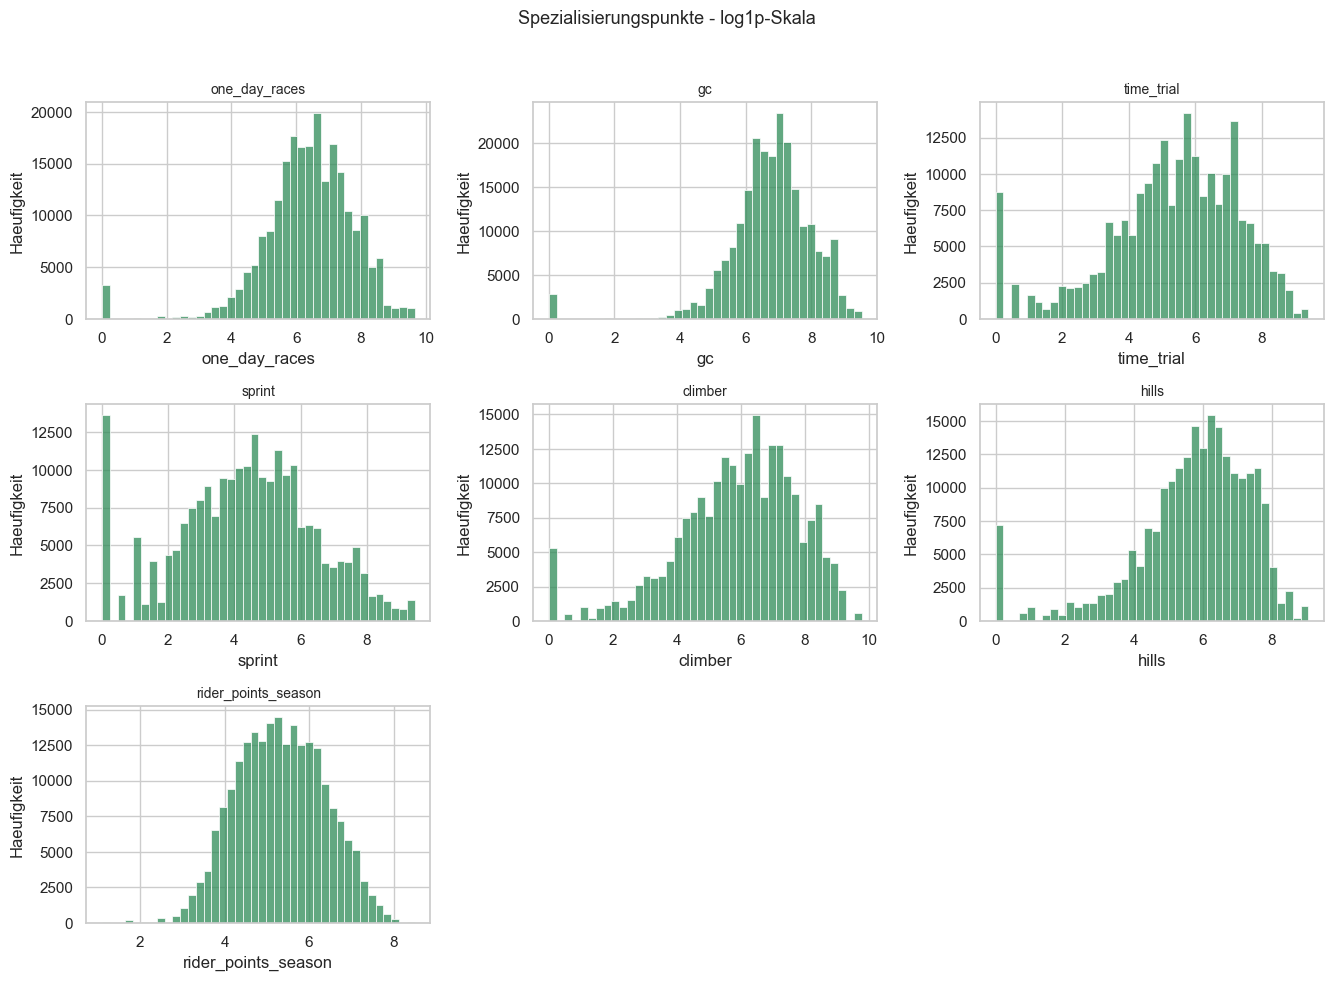

In [13]:
spec_cols = [
    "one_day_races",
    "gc",
    "time_trial",
    "sprint",
    "climber",
    "hills",
    "rider_points_season",
]
spec_cols = [c for c in spec_cols if c in df.columns]

plot_grid(df, spec_cols, kind="hist", ncols=3, title="Spezialisierungspunkte - linear")
plot_grid(df, spec_cols, kind="box", ncols=3, color="lightcoral", title="Spezialisierungspunkte - Boxplots")

df_log = df[spec_cols].apply(lambda s: np.log1p(s.clip(lower=0)))
plot_grid(
    df_log,
    spec_cols,
    kind="hist",
    ncols=3,
    color="seagreen",
    title="Spezialisierungspunkte - log1p-Skala",
)


### Gruppe 4: Wetter

Wetter wird je Etappe an Start (`departure_*`) und Ziel (`arrival_*`) gemessen. Wir zeigen alle linearen Wetter-Größen gemeinsam:

- Temperatur (`*_temp_mittel`, °C)
- Wind (`*_wind_mittel`, km/h)
- Luftfeuchte (`*_luftfeuchte_mittel`, %)
- Regen / Niederschlag (`*_regen_mittel`, `*_niederschlag_mittel`)

**Windrichtung** ist eine zirkuläre Variable und wird **nicht** in dieser linearen Übersicht gezeigt - der reine Mittelwert ist mathematisch unzulässig (0° und 360° sind dasselbe). Sie folgt unten als Polar-Histogramm.

Wetter-Spalten (10):
['departure_temp_mittel', 'departure_regen_mittel', 'departure_wind_mittel', 'departure_luftfeuchte_mittel', 'departure_niederschlag_mittel', 'arrival_temp_mittel', 'arrival_regen_mittel', 'arrival_wind_mittel', 'arrival_luftfeuchte_mittel', 'arrival_niederschlag_mittel']


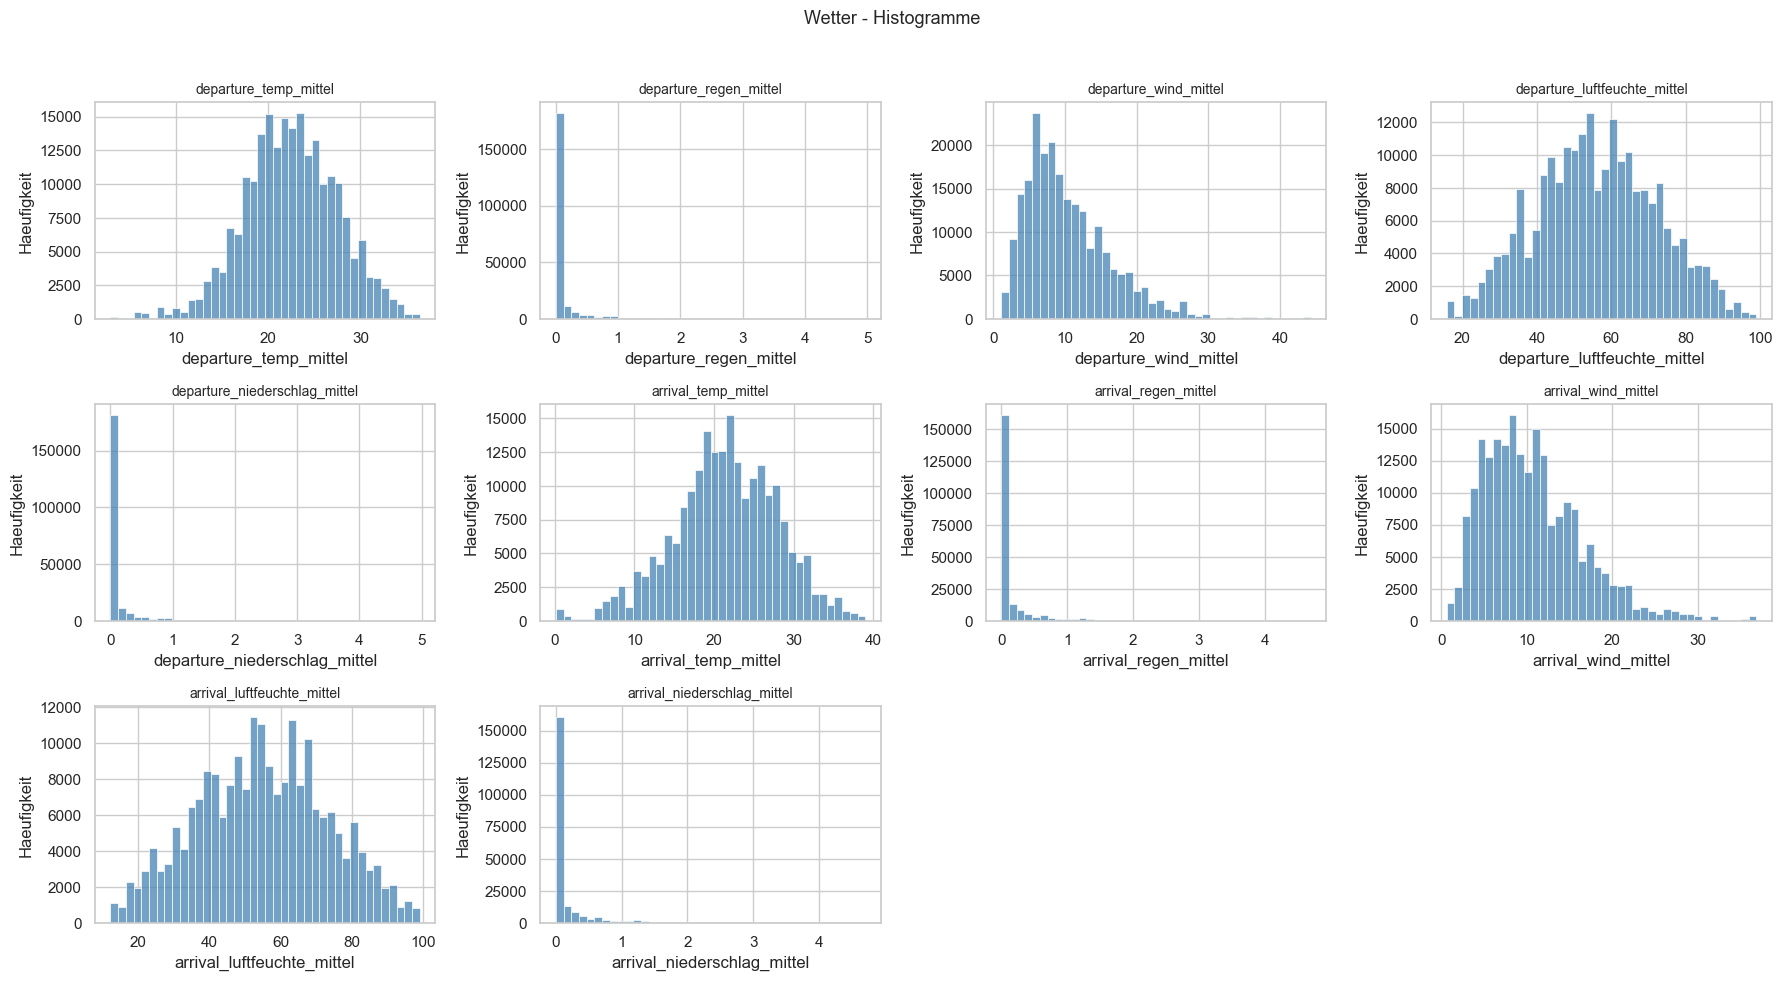

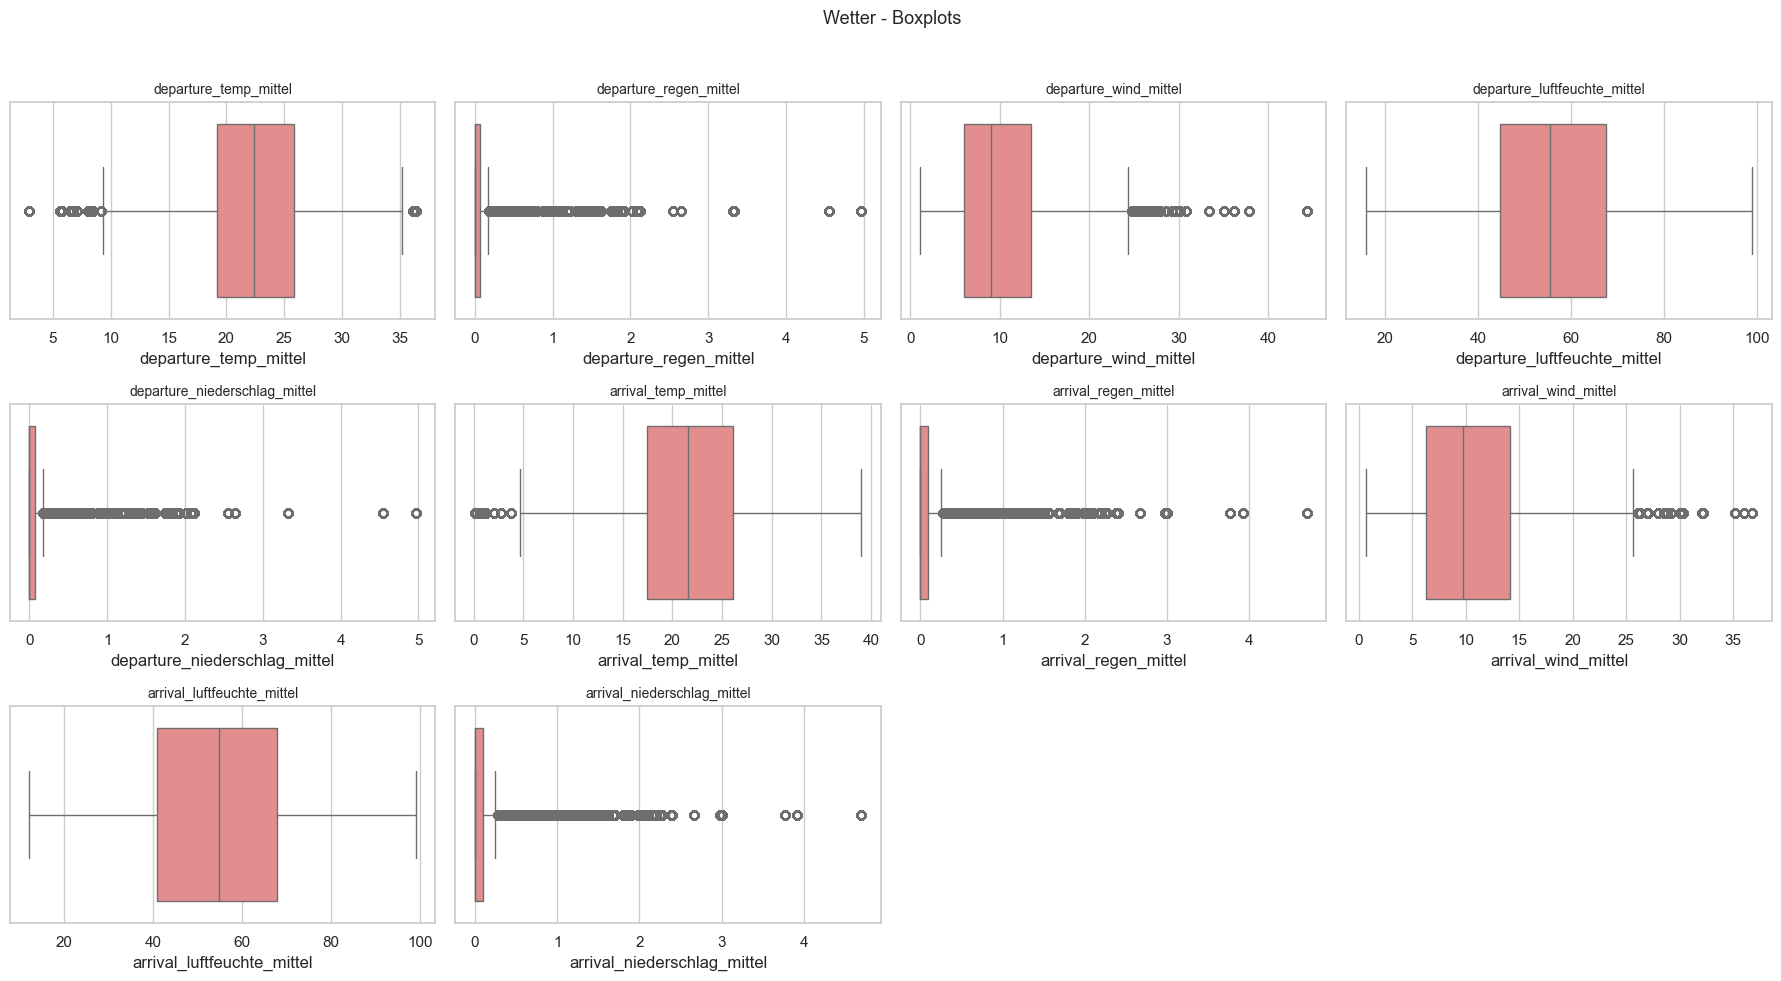

In [14]:
weather_cols = [
    c
    for c in df.columns
    if (c.startswith("departure_") or c.startswith("arrival_"))
    and c not in circular
    and c not in geo
    and pd.api.types.is_numeric_dtype(df[c])
]

print(f"Wetter-Spalten ({len(weather_cols)}):")
print(weather_cols)

plot_grid(df, weather_cols, kind="hist", ncols=4, title="Wetter - Histogramme")
plot_grid(df, weather_cols, kind="box", ncols=4, color="lightcoral", title="Wetter - Boxplots")


### Zirkuläre Variable: Windrichtung

Die Windrichtung in Grad ist **zirkulär**: 0° (Nord) und 360° (Nord) sind identisch. Ein Histogramm in linearer Skala würde nahe 0/360 künstliche "Lücken" oder "Spitzen" produzieren. Korrekt ist eine **Polar-Darstellung** mit 16 Sektoren (entspricht 22.5° pro Sektor).

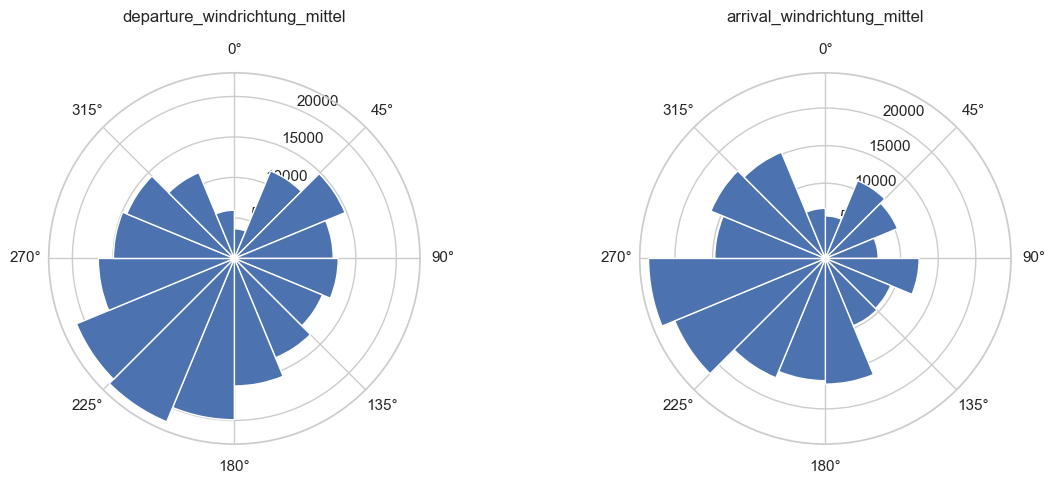

In [15]:
def polar_wind_hist(series: pd.Series, ax, title: str, n_bins: int = 16):
    s = series.dropna() % 360
    bin_edges = np.linspace(0, 360, n_bins + 1)
    counts, _ = np.histogram(s, bins=bin_edges)
    theta = np.deg2rad(bin_edges[:-1])
    width = np.deg2rad(360 / n_bins)
    bars = ax.bar(theta, counts, width=width, bottom=0, align="edge", edgecolor="white")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(title, pad=15)
    return bars


if circular:
    fig, axes = plt.subplots(
        1, len(circular), figsize=(6 * len(circular), 5), subplot_kw={"projection": "polar"}
    )
    axes = np.atleast_1d(axes).flatten()
    for ax, col in zip(axes, circular):
        polar_wind_hist(df[col], ax, col)
    plt.tight_layout()
    plt.show()
else:
    print("Keine zirkulaeren Spalten vorhanden.")


## Skewness und Kurtosis

**Skewness** misst die Asymmetrie einer Verteilung:
- `skew ≈ 0`: symmetrisch (z. B. Normalverteilung).
- `skew > 0`: rechtsschief (langer Schwanz nach rechts) - typisch für Punktesummen, Zähler, Distanzen mit unteren Ausreißern.
- `skew < 0`: linksschief (langer Schwanz nach links) - im Sport-Kontext seltener.

**Kurtosis** misst die "Gewichtung" der Schwänze gegenüber einer Normalverteilung (Excess-Kurtosis: Normalverteilung = 0).

**Faustregel** (nicht hart, aber im Projektkontext sinnvoll):
- `|skew| < 0.5`: weitgehend symmetrisch, keine Transformation nötig.
- `0.5 ≤ |skew| < 1`: moderat schief, Transformation optional.
- `|skew| ≥ 1`: stark schief, Log-/Box-Cox-Transformation oder robuste Skalierung erwägen.

,skew,kurtosis
column,,
departure_regen_mittel,5.60,44.54
departure_niederschlag_mittel,5.60,44.47
sprint,5.36,35.04
arrival_regen_mittel,4.13,22.94
arrival_niederschlag_mittel,4.09,22.45
time_trial,3.56,17.46
one_day_races,3.48,16.36
climber,3.18,14.67
hills,3.06,13.84


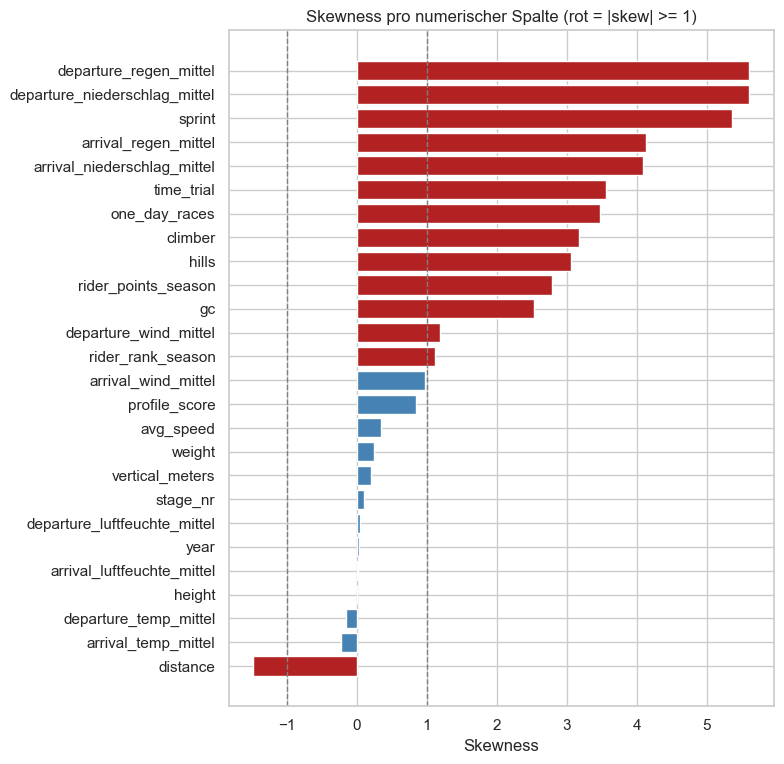

In [16]:
skew_table = (
    num_stats[["skew", "kurtosis"]]
    .assign(abs_skew=lambda x: x["skew"].abs())
    .sort_values("abs_skew", ascending=False)
    .drop(columns="abs_skew")
)
display(skew_table.round(2))

fig, ax = plt.subplots(figsize=(8, max(3, 0.3 * len(skew_table))))
sorted_skew = skew_table["skew"].sort_values()
colors = ["firebrick" if abs(v) >= 1 else "steelblue" for v in sorted_skew]
ax.barh(sorted_skew.index, sorted_skew.values, color=colors)
ax.axvline(1, color="grey", linestyle="--", linewidth=1)
ax.axvline(-1, color="grey", linestyle="--", linewidth=1)
ax.set_xlabel("Skewness")
ax.set_title("Skewness pro numerischer Spalte (rot = |skew| >= 1)")
plt.tight_layout()
plt.show()


## Outlier Detection (IQR-Methode)

Wir verwenden die klassische **Tukey-IQR-Regel**: Werte außerhalb des Intervalls
$$\bigl[Q_1 - 1.5 \cdot IQR,\ Q_3 + 1.5 \cdot IQR\bigr]$$
gelten als statistische Ausreißer. Das ist eine **methodische**, keine **inhaltliche** Bewertung:

- Ein `vertical_meters = 4500` ist statistisch ein Ausreißer, im Sportkontext aber eine völlig plausible Königsetappe.
- Ein `weight = 95 kg` ist im Profi-Radsport sehr ungewöhnlich (mögliche Datenqualitätsfrage), aber statistisch nur mäßig auffällig.

Die Tabelle und das Boxplot-Grid dienen daher als **Heatmap der zu untersuchenden Spalten** - die endgültige Entscheidung "echter Fehler vs. plausible Extremwerte" erfolgt domänenspezifisch im Cleaning-/Imputationsschritt.

In [17]:
def iqr_outliers(df: pd.DataFrame, cols: list[str], k: float = 1.5) -> pd.DataFrame:
    rows = []
    for col in cols:
        s = df[col].dropna()
        if s.empty:
            continue
        q1, q3 = np.percentile(s, [25, 75])
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        outliers = s[(s < lower) | (s > upper)]
        rows.append(
            {
                "column": col,
                "n": int(s.shape[0]),
                "q1": q1,
                "q3": q3,
                "iqr": iqr,
                "lower_bound": lower,
                "upper_bound": upper,
                "min": s.min(),
                "max": s.max(),
                "n_outliers": int(outliers.shape[0]),
                "outlier_pct": round(100 * outliers.shape[0] / s.shape[0], 2),
            }
        )
    return (
        pd.DataFrame(rows)
        .set_index("column")
        .sort_values("outlier_pct", ascending=False)
    )


outlier_table = iqr_outliers(df, numeric_continuous).round(3)
outlier_table


,n,q1,q3,iqr,lower_bound,upper_bound,min,max,n_outliers,outlier_pct
column,,,,,,,,,,
arrival_niederschlag_mittel,214253,0.000,0.100,0.100,-0.150,0.250,0.000,4.70,37370,17.44
arrival_regen_mittel,214253,0.000,0.100,0.100,-0.150,0.250,0.000,4.70,37003,17.27
departure_niederschlag_mittel,222377,0.000,0.070,0.070,-0.105,0.175,0.000,4.97,35000,15.74
departure_regen_mittel,222377,0.000,0.070,0.070,-0.105,0.175,0.000,4.97,34829,15.66
sprint,225692,20.000,322.000,302.000,-433.000,775.000,0.000,12697.00,30388,13.46
distance,225692,153.400,196.500,43.100,88.750,261.150,0.000,264.00,29468,13.06
climber,225692,120.000,1410.000,1290.000,-1815.000,3345.000,0.000,17476.00,25191,11.16
gc,225692,469.000,1838.000,1369.000,-1584.500,3891.500,0.000,13732.00,22096,9.79
time_trial,225692,67.000,923.000,856.000,-1217.000,2207.000,0.000,12022.00,20915,9.27


Top-6 Spalten nach IQR-Outlier-Anteil:
['arrival_niederschlag_mittel', 'arrival_regen_mittel', 'departure_niederschlag_mittel', 'departure_regen_mittel', 'sprint', 'distance']


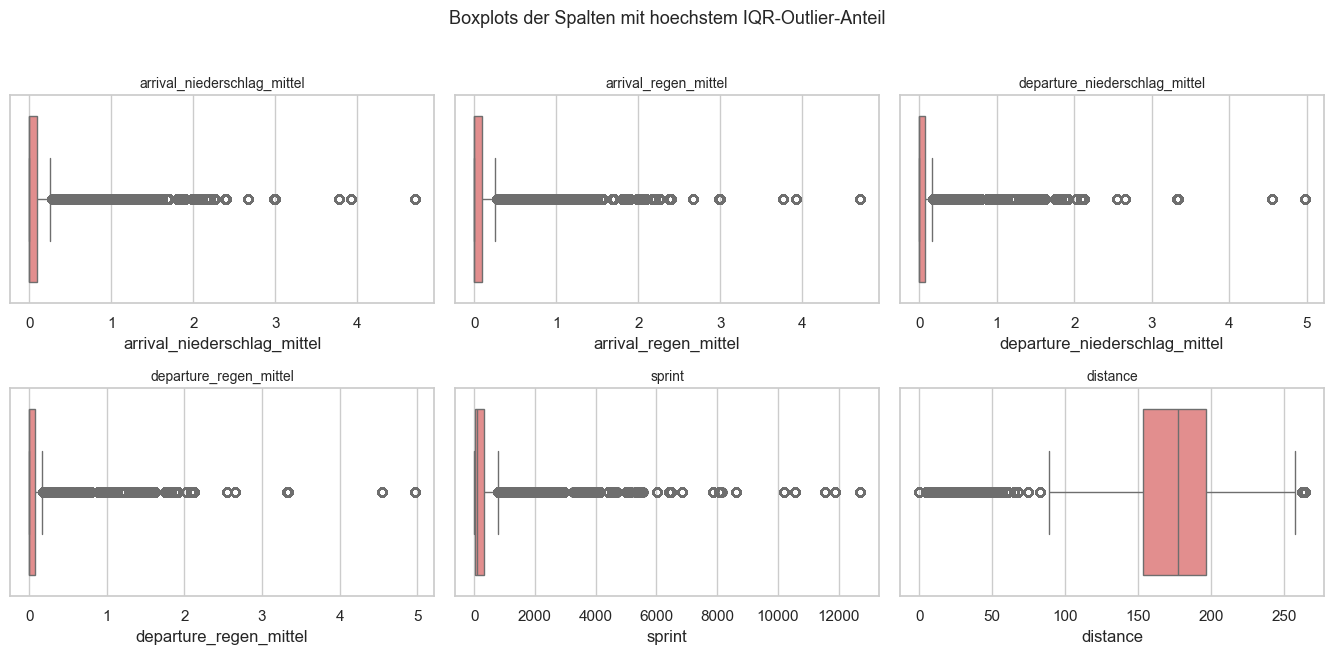

In [18]:
top_outlier_cols = outlier_table.head(6).index.tolist()
print("Top-6 Spalten nach IQR-Outlier-Anteil:")
print(top_outlier_cols)

plot_grid(
    df,
    top_outlier_cols,
    kind="box",
    ncols=3,
    color="lightcoral",
    title="Boxplots der Spalten mit hoechstem IQR-Outlier-Anteil",
)


## Kategoriale Variablen - Bar Charts

Für jede kategoriale Spalte zeigen wir die **Top-15 Ausprägungen** als horizontalen Bar Chart. Bei hochkardinalen Spalten (`current_team`, `departure`, `arrival`) deutet die Restzahl an, wie viele weitere Kategorien existieren - ein Hinweis darauf, ob ein **Frequency-Encoding** oder **Top-N-Bucketing** im Feature-Engineering sinnvoll ist.

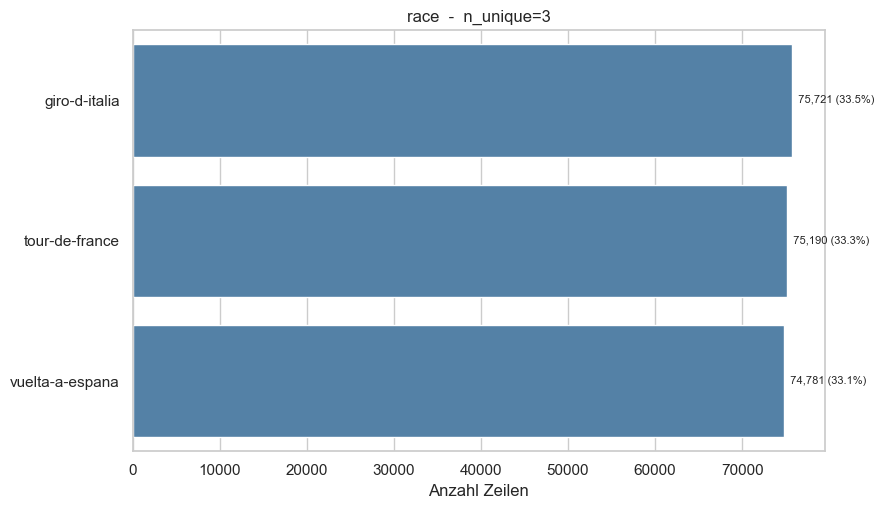

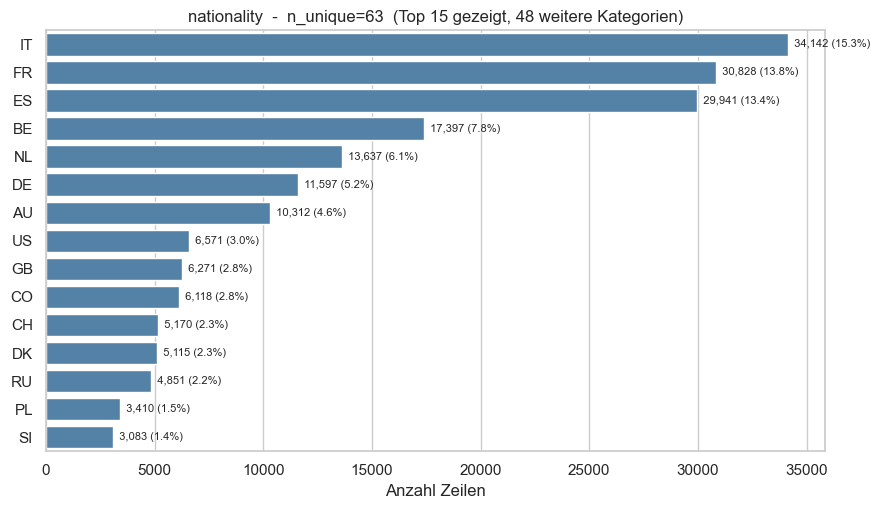

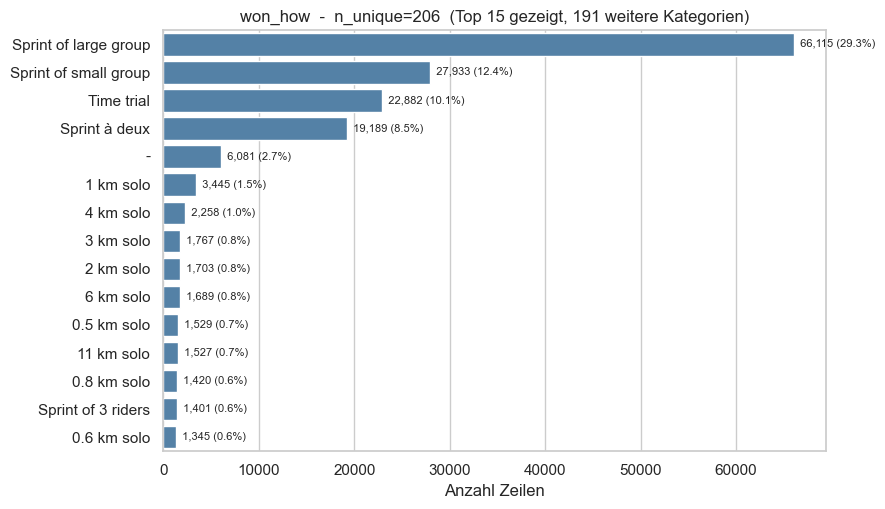

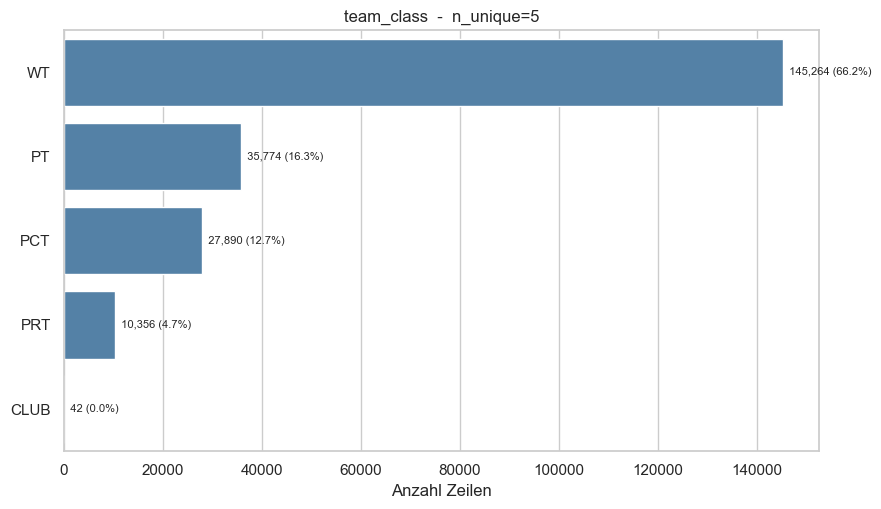

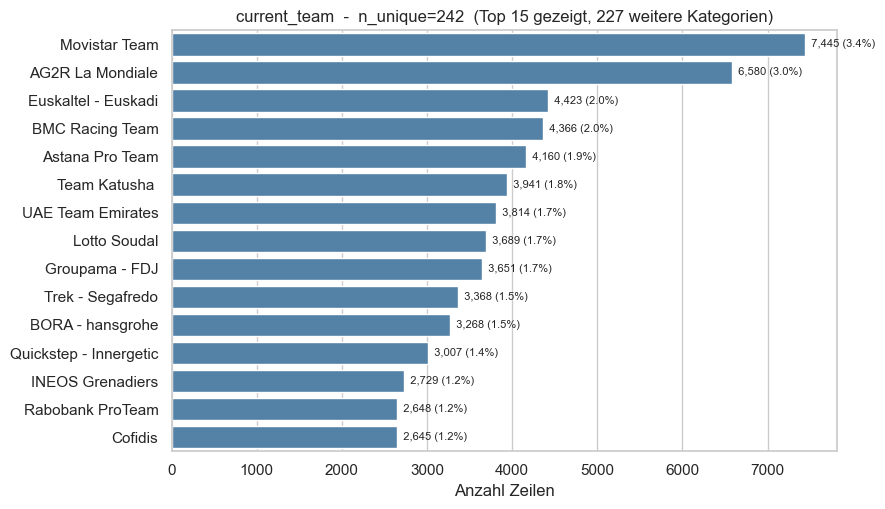

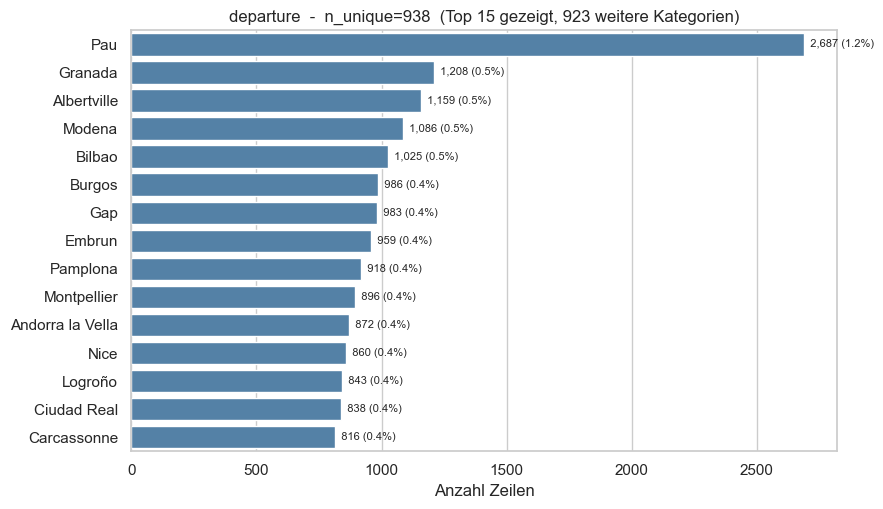

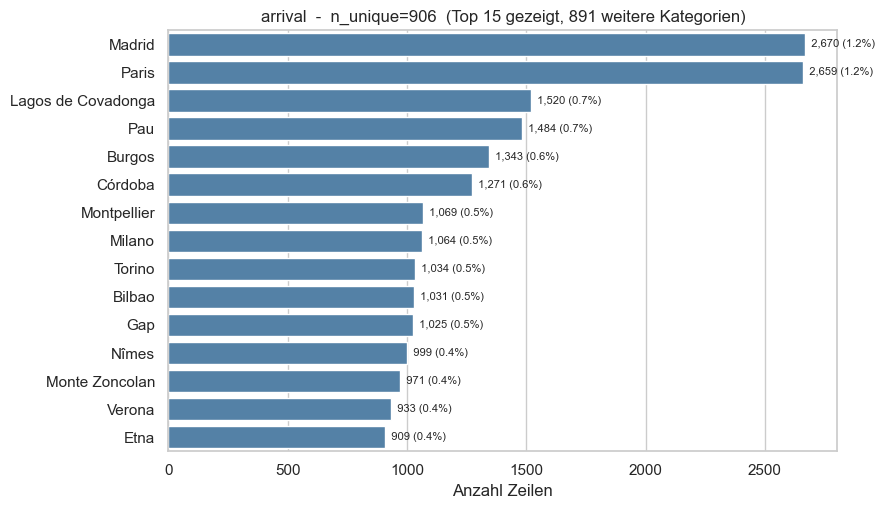

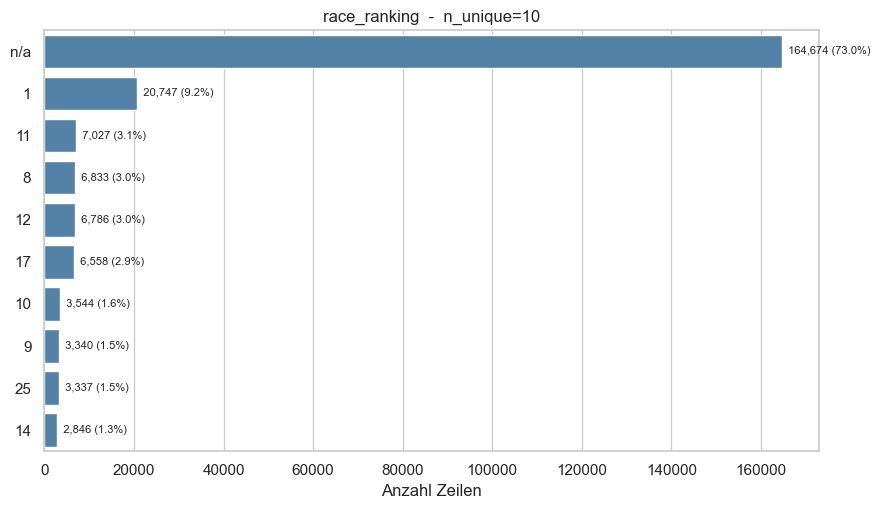

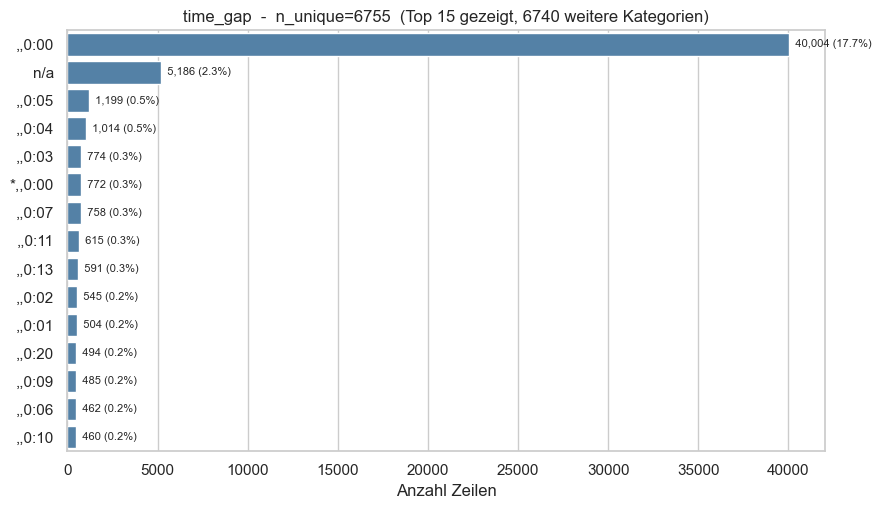

In [19]:
def categorical_barchart(series: pd.Series, top_n: int = 15, ax=None):
    s = series.dropna().astype(str)
    vc = s.value_counts()
    total = len(s)
    top = vc.head(top_n)
    pct = (100 * top / total).round(2)
    other_n = vc.shape[0] - top.shape[0]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(top))))
    sns.barplot(x=top.values, y=top.index, ax=ax, color="steelblue")
    for i, (cnt, p) in enumerate(zip(top.values, pct.values)):
        ax.text(cnt, i, f"  {cnt:,} ({p:.1f}%)", va="center", fontsize=8)

    title = f"{series.name}  -  n_unique={vc.shape[0]}"
    if other_n > 0:
        title += f"  (Top {top_n} gezeigt, {other_n} weitere Kategorien)"
    ax.set_title(title)
    ax.set_xlabel("Anzahl Zeilen")
    ax.set_ylabel("")


for col in categorical:
    fig, ax = plt.subplots(figsize=(9, max(3, 0.35 * 15)))
    categorical_barchart(df[col], top_n=15, ax=ax)
    plt.tight_layout()
    plt.show()


## Zusammenfassung der univariaten Analyse

### Befunde nach Kategorie

**Datenqualität / Missing Values**
- `rank` enthält DNF/DNS-Fälle als `NaN` - das ist Information, kein Fehler. Diese Fälle werden **nicht imputiert**, sondern getrennt modelliert.
- `rider_points_season` und `rider_rank_season` haben Missings für Rookies - hier ist eine `0`-Imputation oder ein "Rookie"-Flag sinnvoll.
- Wetter-Spalten zeigen vereinzelt Missings durch fehlende Geo-Treffer - Median-Imputation pro Renntag ist eine sinnvolle Strategie.
- `weight` und `height` fehlen bei einigen Fahrerprofilen - eine gruppenweise Median-Imputation (z. B. nach `nationality`) ist denkbar.

**Verteilungen / Schiefe**
- Spezialisierungspunkte (`one_day_races`, `gc`, `time_trial`, `sprint`, `climber`, `hills`, `rider_points_season`) sind stark **rechtsschief** - **Log-Transformation** vor dem Modelltraining empfohlen.
- `vertical_meters` und `profile_score` sind ebenfalls rechtsschief mit häufigen Nullen (Flachetappen) - eine separate **Indikatorvariable "Flachetappe"** kann zusätzlichen Mehrwert bringen.
- `height`, `weight` und Wetter-Größen sind annähernd symmetrisch - keine Transformation nötig.

**Outlier**
- IQR-Outlier sind in den Spezialisierungspunkten am häufigsten - **fast alle sind sportlich plausibel** (Top-Fahrer-Effekt) und sollten **nicht** entfernt werden.
- `avg_speed` zeigt vereinzelt Extremwerte über 60 km/h (Zeitfahren mit Rückenwind) - ebenfalls plausibel.
- Punktuelle Auffälligkeiten in `weight` (sehr leicht / sehr schwer) sollten domänenspezifisch geprüft werden, nicht statistisch.

**Kategoriale Variablen**
- `nationality` hat eine Long-Tail-Verteilung mit Dominanz weniger Nationen (FR, BE, IT, ES) - **Top-N-Bucketing** mit "Other"-Kategorie sinnvoll.
- `current_team` ist hochkardinal (>500 Teams über die Jahre) - Frequency-Encoding oder Mapping auf `team_class` ist effizienter als One-Hot.
- `won_how` und `team_class` sind niedrigkardinal und gut für direktes Encoding geeignet.

**Zirkuläre Variablen**
- Windrichtung kann **nicht linear** in das Modell - Empfehlung: in zwei Features `sin(theta)` und `cos(theta)` zerlegen.

### Kandidaten zum Drop oder Recoding
- ID-Spalten (`url`, `rider_url`, `name`, `url_name`) tragen keine direkte Information für das Ranking-Modell - vor dem Training entfernen.
- `time_gap` ist im rohen String-Format aktuell ein Identifikator - vor dem Training in Sekunden parsen oder verwerfen.

### Ausblick: Bivariate Analyse
Die nächste Stufe der Exploration (separates Notebook **04.02**) wird:
- Korrelationen zwischen numerischen Features prüfen (Heatmap, Spearman gegen `rank`).
- Target-Conditional-Verteilungen visualisieren (z. B. `avg_speed` vs. Top-10 / Rest).
- Interaktionen zwischen Renn- und Fahrerprofilen aufzeigen (z. B. `vertical_meters` × `weight`).

---
**Checkpoint:** Die hier gewonnenen Erkenntnisse fließen direkt in das nachfolgende Imputations-, Encoding- und Feature-Engineering-Notebook ein.